## Import Libraries
This section imports all the necessary libraries for data processing, visualization, and machine learning classification.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
import xgboost as xgb
from sklearn.datasets import load_iris

## Dataset
We generated a synthetic dataset containing clinical indicators relevant for ICU (reanimation) need prediction. The features include age, heart rate, blood pressure, respiratory rate, oxygen saturation, temperature, Glasgow score, and a target variable indicating ICU requirement.

In [2]:
def generate_initial_dataset(n_patients=5000):
    np.random.seed(42)

    data = {
        'age': np.random.normal(65, 18, n_patients).clip(18, 95),

        'frequence_cardiaque': np.random.normal(85, 25, n_patients).clip(35, 190),
        'tension_systolique': np.random.normal(125, 25, n_patients).clip(65, 195),
        'frequence_respiratoire': np.random.normal(18, 7, n_patients).clip(6, 45),
        'spo2': np.random.normal(94, 7, n_patients).clip(75, 100),
        'temperature': np.random.normal(37.2, 1.2, n_patients).clip(34.5, 41.5),
        'glasgow': np.random.choice(range(3, 16), n_patients,
                                  p=[0.02, 0.02, 0.03, 0.03, 0.05, 0.05, 0.05, 0.05, 0.05, 0.1, 0.15, 0.2, 0.2])
    }

    df = pd.DataFrame(data)

    risk_score = (
        -0.3 * df['spo2'] +
        -0.35 * df['glasgow'] +
        0.2 * abs(df['frequence_respiratoire'] - 15) +
        -0.25 * df['tension_systolique'] +
        0.015 * df['age'] +
        np.random.normal(0, 1.5, n_patients)
    )

    # Utilisation d'un seuil pour obtenir environ 40% de cas positifs
    seuil = np.percentile(risk_score, 60)
    df['besoin_reanimation'] = (risk_score > seuil).astype(int)

    return df

# Générer le dataset
df = generate_initial_dataset(5000)



In [3]:
df.head()

,age,frequence_cardiaque,tension_systolique,frequence_respiratoire,spo2,temperature,glasgow,besoin_reanimation
0,73.940855,74.406008,108.037632,16.996037,96.438004,37.405048,15,1
1,62.511243,73.664647,117.362513,17.771409,95.983265,37.214707,15,0
2,76.658394,40.108921,110.065473,18.450064,87.444361,36.682614,12,1
3,92.414537,76.747745,127.760451,24.628030,98.057090,37.196968,12,0
4,60.785239,103.320727,154.929463,12.769479,83.569421,37.789010,14,0



Distribution de la variable cible :
besoin_reanimation
0    0.6
1    0.4
Name: proportion, dtype: float64


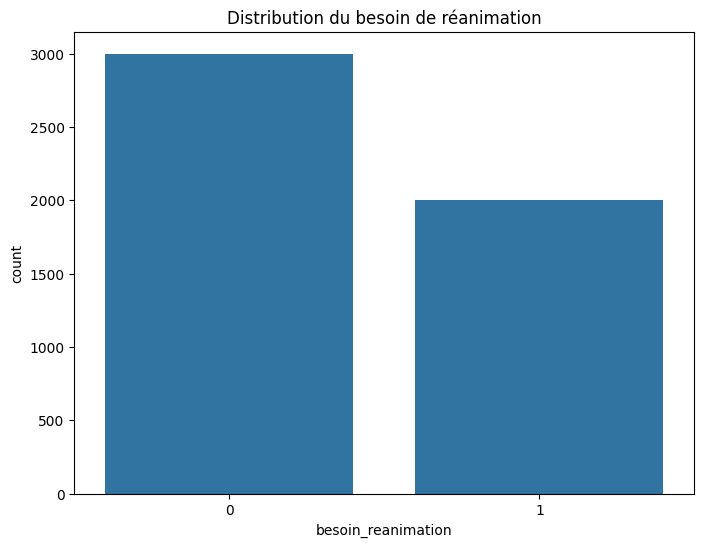

In [4]:
# Afficher la distribution de la variable cible
print("\nDistribution de la variable cible :")
print(df['besoin_reanimation'].value_counts(normalize=True))

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='besoin_reanimation')
plt.title('Distribution du besoin de réanimation')
plt.show()

## Outlier Detection and Treatment
This section defines functions to detect and handle outliers in the dataset using the Interquartile Range (IQR) method. Outliers are visualized with boxplots, and then replaced with boundary values to reduce their impact. This helps ensure the data is clean and suitable for machine learning models.

Nombre d'outliers par variable avant traitement:
age: 0 outliers
frequence_cardiaque: 17 outliers
tension_systolique: 19 outliers
frequence_respiratoire: 15 outliers
spo2: 0 outliers
temperature: 15 outliers

Boxplots avant traitement des outliers:


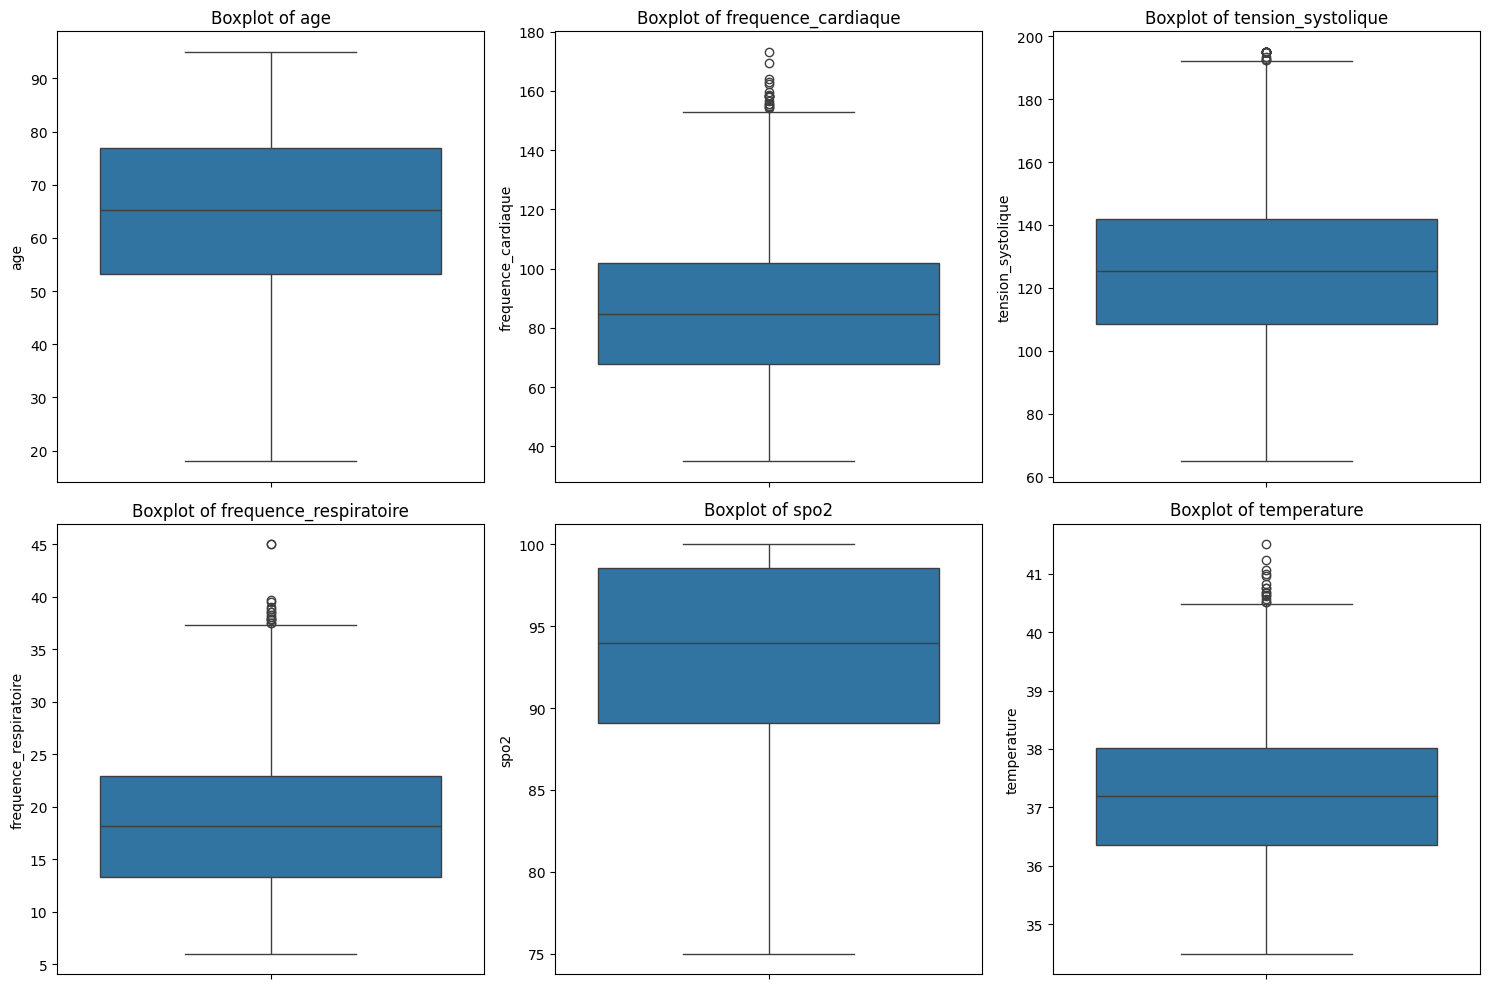


Nombre d'outliers par variable après traitement:
age: 0 outliers
frequence_cardiaque: 0 outliers
tension_systolique: 0 outliers
frequence_respiratoire: 0 outliers
spo2: 0 outliers
temperature: 0 outliers

Boxplots après traitement des outliers:


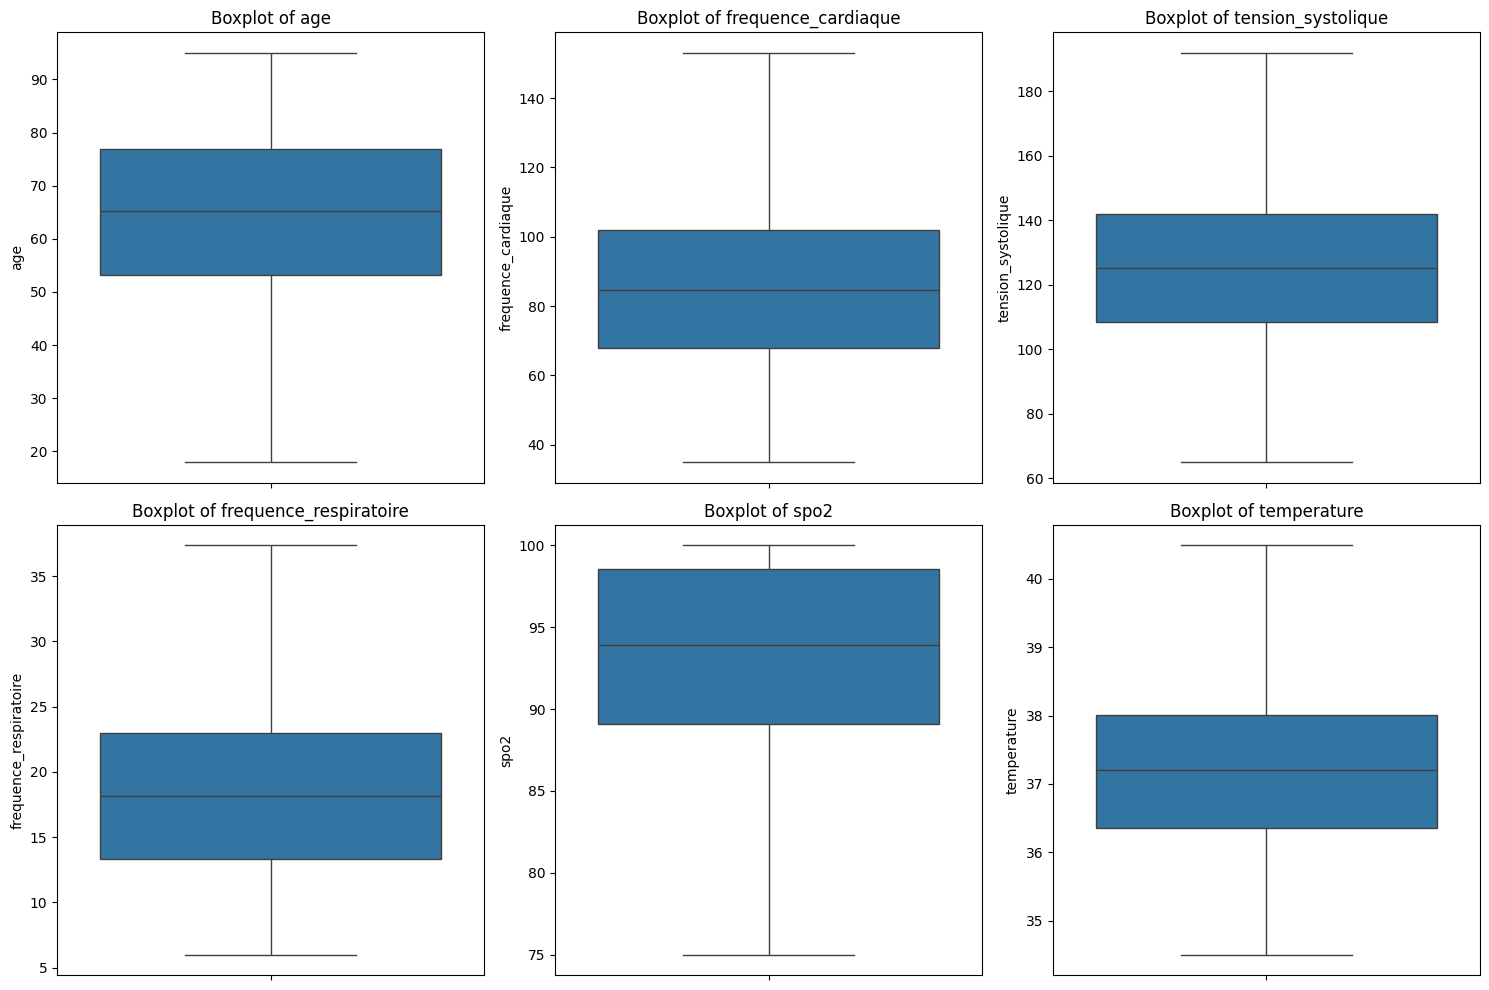


Statistiques descriptives avant traitement:
               age  frequence_cardiaque  tension_systolique  \
count  5000.000000          5000.000000         5000.000000   
mean     64.776783            84.971045          125.326022   
std      17.127036            24.741829           24.673108   
min      18.000000            35.000000           65.000000   
25%      53.157709            67.835427          108.477841   
50%      65.242381            84.563737          125.247936   
75%      76.988191           101.930952          141.888356   
max      95.000000           173.226380          195.000000   

       frequence_respiratoire         spo2  temperature  
count             5000.000000  5000.000000  5000.000000  
mean                18.241863    93.171539    37.196483  
std                  6.742541     5.798735     1.188095  
min                  6.000000    75.000000    34.500000  
25%                 13.347235    89.087679    36.360929  
50%                 18.134814    93.943

In [5]:
#Fonction pour détecter les outliers avec IQR
def detect_outliers(df, columns):
    outliers_dict = {}
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
        outliers_dict[column] = len(outliers)
    return outliers_dict

# 3. Visualisation des outliers avec des boxplots
def plot_outliers(df, columns, figsize=(15, 10)):
    plt.figure(figsize=figsize)
    for i, column in enumerate(columns, 1):
        plt.subplot(2, 3, i)
        sns.boxplot(data=df, y=column)
        plt.title(f'Boxplot of {column}')
    plt.tight_layout()
    plt.show()

# 4. Traitement des outliers
def handle_outliers(df, columns):
    df_clean = df.copy()
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Remplacer les outliers par les bornes
        df_clean.loc[df_clean[column] < lower_bound, column] = lower_bound
        df_clean.loc[df_clean[column] > upper_bound, column] = upper_bound

    return df_clean

# Colonnes numériques à vérifier pour les outliers
numeric_columns = ['age', 'frequence_cardiaque', 'tension_systolique',
                  'frequence_respiratoire', 'spo2', 'temperature']

# Afficher les outliers avant traitement
print("Nombre d'outliers par variable avant traitement:")
outliers_before = detect_outliers(df, numeric_columns)
for col, count in outliers_before.items():
    print(f"{col}: {count} outliers")

# Visualiser les boxplots avant traitement
print("\nBoxplots avant traitement des outliers:")
plot_outliers(df, numeric_columns)

# Traiter les outliers
df_clean = handle_outliers(df, numeric_columns)

# Afficher les outliers après traitement
print("\nNombre d'outliers par variable après traitement:")
outliers_after = detect_outliers(df_clean, numeric_columns)
for col, count in outliers_after.items():
    print(f"{col}: {count} outliers")

# Visualiser les boxplots après traitement
print("\nBoxplots après traitement des outliers:")
plot_outliers(df_clean, numeric_columns)

# Comparer les statistiques descriptives avant/après
print("\nStatistiques descriptives avant traitement:")
print(df[numeric_columns].describe())
print("\nStatistiques descriptives après traitement:")
print(df_clean[numeric_columns].describe())

# S

In [6]:
df.head()

,age,frequence_cardiaque,tension_systolique,frequence_respiratoire,spo2,temperature,glasgow,besoin_reanimation
0,73.940855,74.406008,108.037632,16.996037,96.438004,37.405048,15,1
1,62.511243,73.664647,117.362513,17.771409,95.983265,37.214707,15,0
2,76.658394,40.108921,110.065473,18.450064,87.444361,36.682614,12,1
3,92.414537,76.747745,127.760451,24.628030,98.057090,37.196968,12,0
4,60.785239,103.320727,154.929463,12.769479,83.569421,37.789010,14,0


## Feature Standardization
This section standardizes the numerical features using the StandardScaler. Standardization transforms the data so that each feature has a mean of 0 and a standard deviation of 1. This is important for many machine learning algorithms, as it ensures all features contribute equally and prevents bias due to different scales.

In [7]:

# Liste des colonnes à standardiser
columns_to_scale = ['age', 'frequence_cardiaque', 'tension_systolique',
                    'frequence_respiratoire', 'spo2', 'temperature', 'glasgow']

# Créer une copie du DataFrame original
df_scaled = df.copy()

# Initialiser le StandardScaler
scaler = StandardScaler()

# Appliquer la standardisation
df_scaled[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Vérifier les résultats
print("Vérification après standardisation :")
print("\nMoyennes (devraient être proches de 0) :")
print(df_scaled[columns_to_scale].mean())
print("\nÉcarts-types (devraient être proches de 1) :")
print(df_scaled[columns_to_scale].std())



Vérification après standardisation :

Moyennes (devraient être proches de 0) :
age                      -1.165290e-16
frequence_cardiaque      -2.231104e-16
tension_systolique       -4.490630e-16
frequence_respiratoire    5.297096e-16
spo2                     -5.172751e-16
temperature              -1.125500e-15
glasgow                  -1.200817e-16
dtype: float64

Écarts-types (devraient être proches de 1) :
age                       1.0001
frequence_cardiaque       1.0001
tension_systolique        1.0001
frequence_respiratoire    1.0001
spo2                      1.0001
temperature               1.0001
glasgow                   1.0001
dtype: float64


## Data Splitting
Split the dataset into features (X) and target (y), then into training and test sets for model evaluation.

In [8]:
# Définir X (features) et y (target)
X = df_scaled[columns_to_scale]
y = df['besoin_reanimation']

# Vérifier les shapes
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("\nDistribution de la variable cible:")
print(y.value_counts(normalize=True))

Shape de X: (5000, 7)
Shape de y: (5000,)

Distribution de la variable cible:
besoin_reanimation
0    0.6
1    0.4
Name: proportion, dtype: float64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTailles des ensembles:")
print("Train:", X_train.shape)
print("Test:", X_test.shape)


Tailles des ensembles:
Train: (4000, 7)
Test: (1000, 7)


## Model Training
Train different classification models on the training data and evaluate their performance.

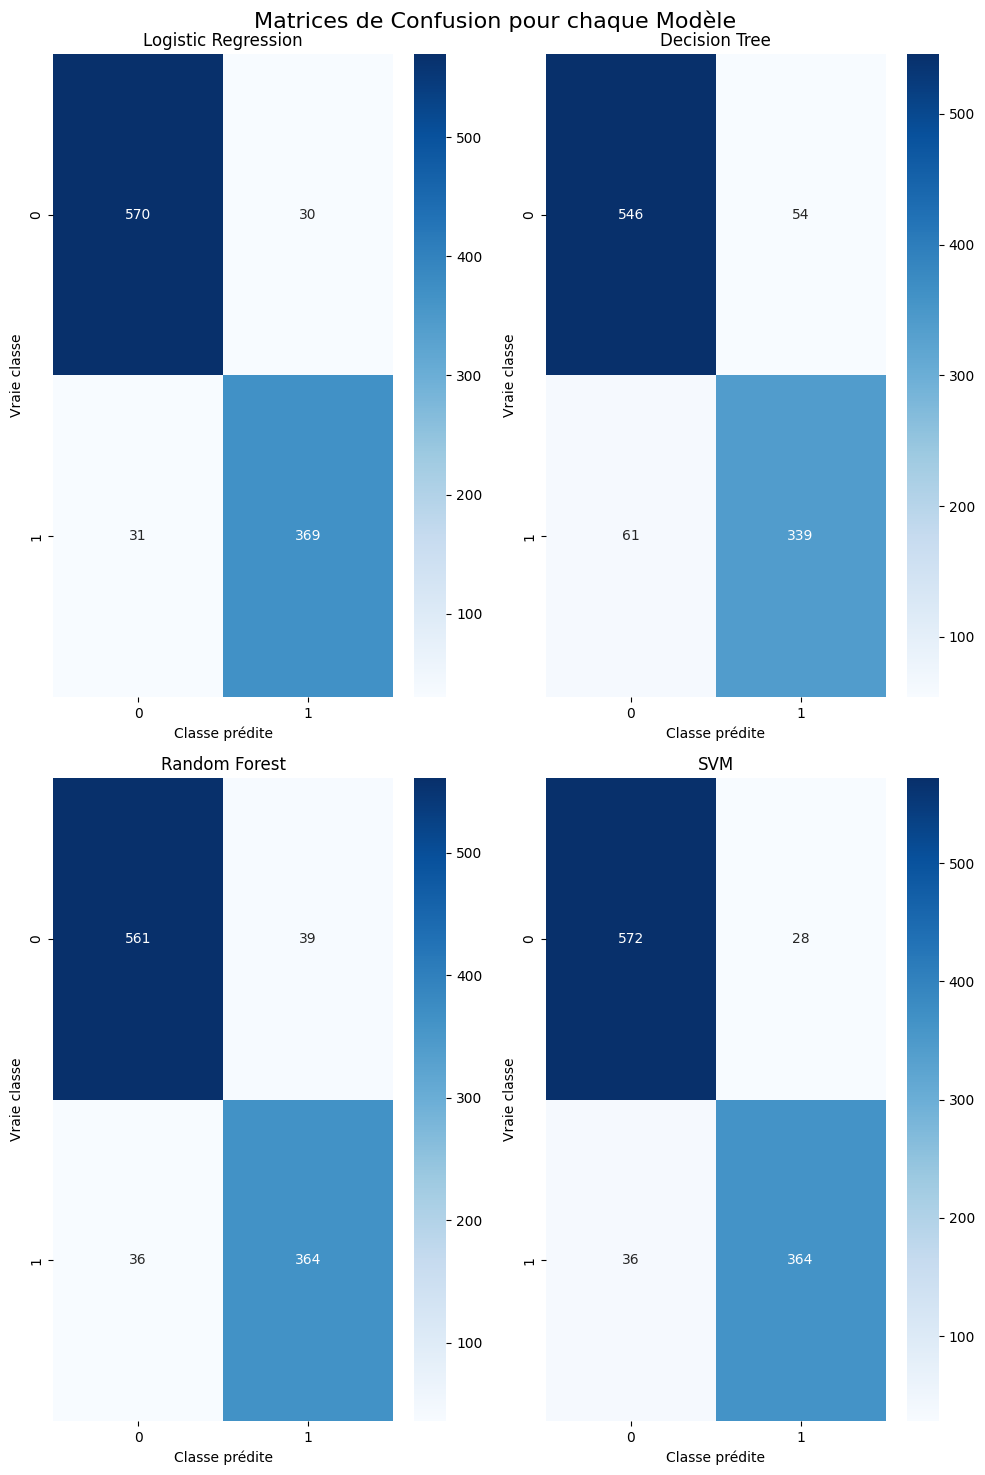

In [10]:
# Affichage des matrices de confusion


# Liste des modèles
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

# Création des matrices de confusion
fig, axes = plt.subplots(2, 2, figsize=(10, 15))
fig.suptitle('Matrices de Confusion pour chaque Modèle', fontsize=16)

for (name, model), ax in zip(models.items(), axes.ravel()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name}')
    ax.set_ylabel('Vraie classe')
    ax.set_xlabel('Classe prédite')

plt.tight_layout()
plt.show()

## Model Comparison and SVM Selection
In this section, we compare the performance of several classification models: Logistic Regression, Decision Tree, Random Forest, and SVM. After evaluating their results, we found that SVM achieved the best performance on our dataset. Therefore, we focused on optimizing the SVM model further using grid search to find the best hyperparameters.

In [11]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp+tn)/(tp+tn+fp+fn)
    precision = tp/(tp+fp) #cad combien des predictions positives du modele sont reellement correctes
    recall = tp/(tp+fn) #Parmi toutes les instances réellement positives, combien ont été correctement identifiées par le modèle ?
    f1 = f1_score(y_test, y_pred) #Le F1-score est la moyenne harmonique de la précision et du rappel. Il équilibre les deux mesures et est utile lorsque vous avez besoin d'un compromis entre précision et rappel

    print(f"\nMétriques pour {name}:")
    print("-"*40)
    print(f"Matrice de confusion:")
    print(f"Vrais Négatifs (TN): {tn}")
    print(f"Faux Positifs (FP): {fp}")
    print(f"Faux Négatifs (FN): {fn}")
    print(f"Vrais Positifs (TP): {tp}")
    print(f"\nScores:")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-Score: {f1:.3f}")
    print("="*60)


Métriques pour Logistic Regression:
----------------------------------------
Matrice de confusion:
Vrais Négatifs (TN): 570
Faux Positifs (FP): 30
Faux Négatifs (FN): 31
Vrais Positifs (TP): 369

Scores:
Accuracy: 0.939
Precision: 0.925
Recall: 0.922
F1-Score: 0.924

Métriques pour Decision Tree:
----------------------------------------
Matrice de confusion:
Vrais Négatifs (TN): 546
Faux Positifs (FP): 54
Faux Négatifs (FN): 61
Vrais Positifs (TP): 339

Scores:
Accuracy: 0.885
Precision: 0.863
Recall: 0.848
F1-Score: 0.855

Métriques pour Random Forest:
----------------------------------------
Matrice de confusion:
Vrais Négatifs (TN): 561
Faux Positifs (FP): 39
Faux Négatifs (FN): 36
Vrais Positifs (TP): 364

Scores:
Accuracy: 0.925
Precision: 0.903
Recall: 0.910
F1-Score: 0.907

Métriques pour SVM:
----------------------------------------
Matrice de confusion:
Vrais Négatifs (TN): 572
Faux Positifs (FP): 28
Faux Négatifs (FN): 36
Vrais Positifs (TP): 364

Scores:
Accuracy: 0.936
Pre

## ROC Curve Explanation
This section plots the ROC curves for each model, which visualize the trade-off between sensitivity (true positive rate) and specificity (1 - false positive rate). The Area Under the Curve (AUC) is a summary metric: a higher AUC means better model discrimination between classes.

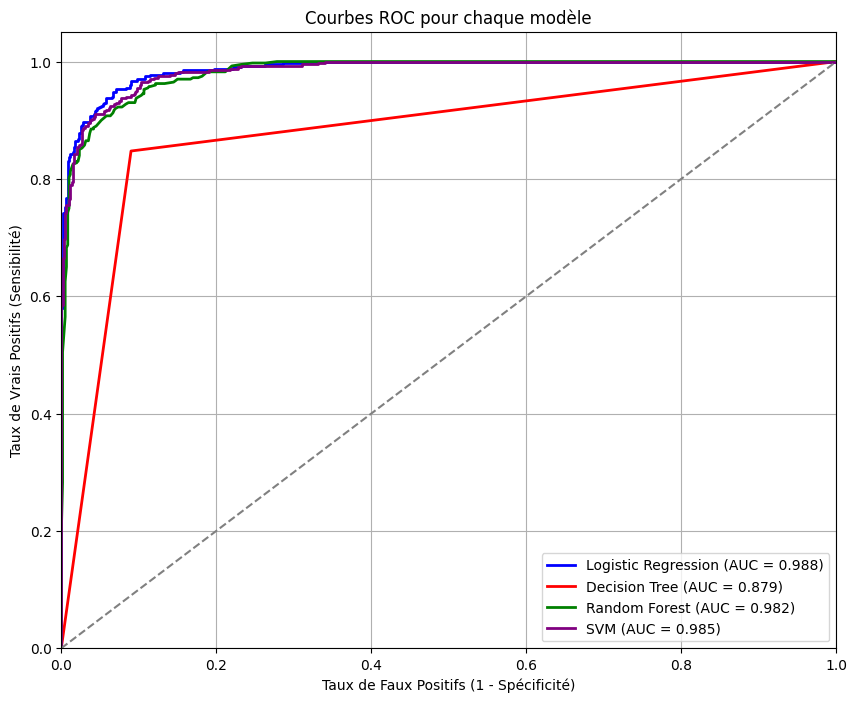

In [12]:
# Créer la figure
plt.figure(figsize=(10, 8))

# Couleurs pour chaque modèle
colors = ['blue', 'red', 'green', 'purple']

# Pour chaque modèle
for (name, model), color in zip(models.items(), colors):
    # Pour SVM, on doit activer probability=True
    if name == 'SVM':
        model = SVC(probability=True, random_state=42)


    model.fit(X_train, y_train)

    # Calculer les probabilités
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculer la courbe ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Tracer la courbe
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_auc:.3f})')

# Ajouter la ligne de référence
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Personnaliser le graphique
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (1 - Spécificité)')
plt.ylabel('Taux de Vrais Positifs (Sensibilité)')
plt.title('Courbes ROC pour chaque modèle')
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

## SVM Hyperparameter Tuning
Since SVM performed best in our initial comparison, we use grid search to find the optimal hyperparameters (like C, kernel, and gamma) for the SVM model. This helps maximize its predictive performance.
But in our case here, it didn't improve the accuracy (gave the same accuracy with the default parameters)

In [13]:
# Définir la grille de paramètres à tester
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'probability': [True]  # Nécessaire pour ROC curve
}

# Créer et exécuter la recherche sur grille
svm = SVC(random_state=42)
grid_search = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Entraîner avec recherche sur grille
grid_search.fit(X_train, y_train)

# Afficher les résultats
print("Meilleurs paramètres:", grid_search.best_params_)
print("Meilleur score:", grid_search.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Meilleurs paramètres: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf', 'probability': True}
Meilleur score: 0.9851067708333332


In [14]:
# Créer le modèle final avec les meilleurs paramètres
best_svm = SVC(
    C=100,
    kernel='rbf',
    gamma=0.01,
    probability=True,
    random_state=42
)

# Entraîner le modèle
best_svm.fit(X_train, y_train)

# Faire des prédictions
y_pred = best_svm.predict(X_test)
y_prob = best_svm.predict_proba(X_test)[:, 1]

# Évaluer le modèle final
from sklearn.metrics import classification_report, roc_auc_score

print("\nRapport de classification:")
print(classification_report(y_test, y_pred))

# Calculer et afficher l'AUC-ROC correctement
auc_roc = roc_auc_score(y_test, y_prob)
print(f"\nAUC-ROC Score: {auc_roc:.3f}")
## Calculer et afficher l'accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.3f}")


Rapport de classification:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       600
           1       0.92      0.92      0.92       400

    accuracy                           0.94      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.94      0.94      0.94      1000


AUC-ROC Score: 0.987

Accuracy: 0.936


## Cross-Validation Explanation
Here, we use cross-validation to check the stability and generalizability of the optimized SVM model. The model is trained and tested on different splits of the data, and the resulting scores show how consistent its performance is across the dataset.

In [15]:
cv_scores = cross_val_score(best_svm, X, y, cv=5)
print(f"Scores de validation croisée: {cv_scores}")


Scores de validation croisée: [0.922 0.933 0.929 0.94  0.923]


### The model's performance is consistent and not due to a lucky train/test split.

## Learning Curves Plot Explanation
This section plots the learning curves for the SVM model, showing how accuracy changes for both the training and test sets as the number of training samples increases. Learning curves help diagnose overfitting, underfitting, and whether adding more data could improve model performance.
In this plot, we have a small gap between the test and training scores ( less than 0.01 in accuracy)

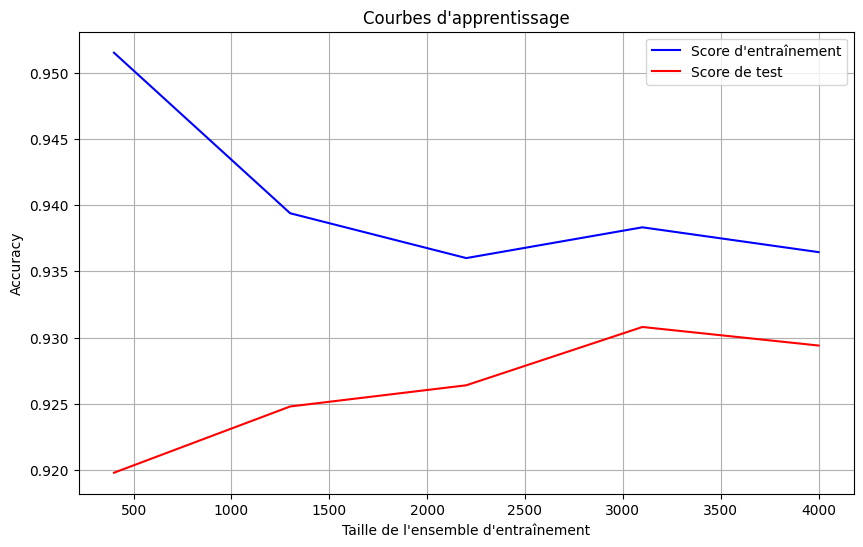

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(best_svm, X, y, cv=5)

# Calculer les moyennes et les écarts-types
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Tracer les courbes
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Score d\'entraînement', color='blue')
plt.plot(train_sizes, test_mean, label='Score de test', color='red')
plt.title('Courbes d\'apprentissage')
plt.xlabel('Taille de l\'ensemble d\'entraînement')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

## Model Saving


In [ ]:
from joblib import dump


dump(best_svm, 'reanimation_model.pkl')

print("Model saved as 'svm_model.pkl'")


Model saved as 'svm_model.pkl'


## XGBoost Classifier
This section introduces the XGBoost classifier, a powerful gradient boosting algorithm. We train and evaluate XGBoost as an alternative to SVM, and compare its performance using accuracy and other metrics.

In [18]:
model = xgb.XGBClassifier( eval_metric='mlogloss')
model.fit(X_train, y_train)

# Faire des prédictions
y_pred = model.predict(X_test)

# Évaluer la précision
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.93


## Saving the XGBoost Model
This section saves the trained XGBoost model to a file. Saving allows you to deploy or reuse the model for future predictions without retraining.

In [ ]:
import joblib
joblib.dump(model, 'model.pkl')  # Replace `model` with your trained model variable
